In [64]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)

import functions_general as fxns
import functions_preprocessing as pre 
import functions_point_to_ftpt as pt_ftpt 
import functions_disagreement_and_gaps as resolve

In [65]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4269' # Used for plotting 

# HAYWARD BOUNDS
xbounds = [-122.15, -122.02]
ybounds = [37.60, 37.69]

# Define the color palette
stanford_palette = [
    "#034185", 
    "#a14059",  
    "#277b8eff",  
    "#ace1fbff",    
    "#a7a7d6ff",
    "#f6c85f", # Yellow
    "#c27ba0"] # Rose

# Set the palette in seaborn
sns.set_palette(sns.color_palette(stanford_palette))
colors = stanford_palette
# Set the palette in seaborn
sns.set_palette(sns.color_palette(stanford_palette))
colors = stanford_palette

In [66]:
## LOAD RESULTS 

models = ['Abrahamson_Silva_Kamai_2014','Boore_Stewart_Seyhan_Atkinson_2014','Campbell_Bozorgnia_2014','Chiou_Youngs_2014']
results1 = pd.read_csv('./R2D_Analysis/Inventories/Synthesized_National/Results_Abrahamson_Silva_Kamai_2014.csv')
results2 = pd.read_csv('./R2D_Analysis/Inventories/Synthesized_National/Results_Boore_Stewart_Seyhan_Atkinson_2014.csv')
results3 = pd.read_csv('./R2D_Analysis/Inventories/Synthesized_National/Results_Campbell_Bozorgnia_2014.csv')
results4 = pd.read_csv('./R2D_Analysis/Inventories/Synthesized_National/Results_Chiou_Youngs_2014.csv')

results = [results1, results2, results3, results4]

In [67]:
ds1 = []
ds2 = []
ds3 = []
ds4 = []
high_damage_bldgs = []

for result in results: 

    ## Collect number of damaged buildings 
    ds1.append(len(result[result['DS']==1]))
    ds2.append(len(result[result['DS']==2]))
    ds3.append(len(result[result['DS']==3]))
    ds4.append(len(result[result['DS']==4]))


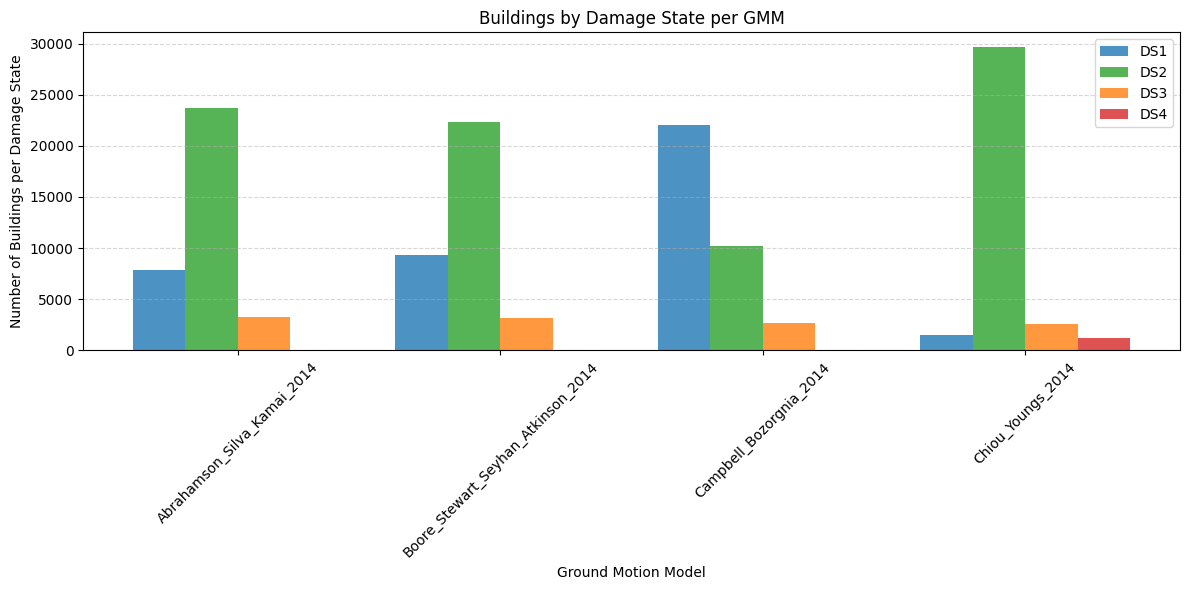

In [68]:
# Number of results (simulations/scenarios)
n_results = len(results)
x = np.arange(n_results)  # x positions for each result
width = 0.2               # width of each bar

fig, ax = plt.subplots(figsize=(12, 6))

# Plot one group of bars per damage state
bars1 = ax.bar(x - 1.5*width, ds1, width, label='DS1',    color='tab:blue',  alpha=0.8)
bars2 = ax.bar(x - 0.5*width, ds2, width, label='DS2',  color='tab:green', alpha=0.8)
bars3 = ax.bar(x + 0.5*width, ds3, width, label='DS3', color='tab:orange', alpha=0.8)
bars4 = ax.bar(x + 1.5*width, ds4, width, label='DS4',  color='tab:red',    alpha=0.8)

# Labels and formatting
ax.set_xlabel('Ground Motion Model')
ax.set_ylabel('Number of Buildings per Damage State')
ax.set_title('Buildings by Damage State per GMM')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [69]:
res_classes = ["RES2", "RES1", "RES3"]
# res_classes = ["RES2", "RES1", "RES3A","RES3B","RES3C","RES3D","RES3E","RES3F"]

counts = []

for df, name in zip(results, models):

    # filter to DS >= 3
    df_filt = df[df["DS"] >= 3]

    # count entries containing each RES class
    c = pd.Series(
        {
            res: df_filt["OccupancyClass_Actual"].str.contains(res, na=False).sum()
            for res in res_classes
        },
        name=name
    )

    counts.append(c)

count_df = pd.concat(counts, axis=1)


In [70]:
res_classes = ["RES2", "RES1", "RES3A","RES3B","RES3C","RES3D","RES3E","RES3F"]
res_classes = ["RES2", "RES1", "RES3"]

counts = []

for df, name in zip(results, models):

    # filter to DS >= 3
    df_filt = df[df["DS"] >= 3]

    # sum NumberOfUnits for each RES class
    c = pd.Series(
        {
            res: df_filt.loc[
                df_filt["OccupancyClass_Actual"].str.contains(res, na=False),
                "NumberOfUnits"
            ].sum()
            for res in res_classes
        },
        name=name
    )

    counts.append(c)

units_df = pd.concat(counts, axis=1)


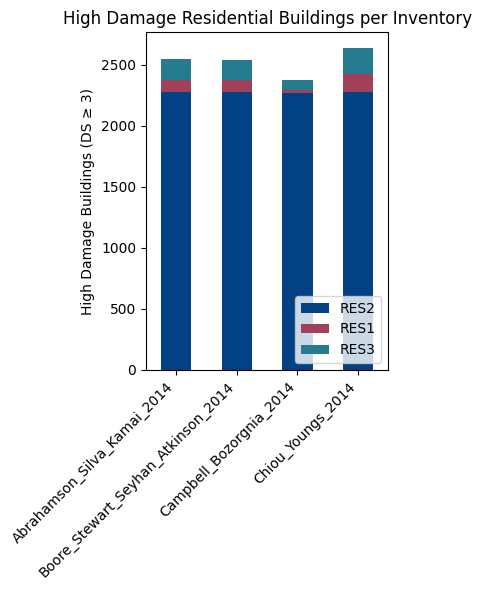

In [ ]:

fig, ax = plt.subplots(figsize=(4, 6))
count_df.T.plot(kind="bar",stacked=True,ax=ax) #, color = colors) #[colors[3],colors[2],colors[0]])

ax.set_ylabel("High Damage Buildings (DS ≥ 3)")
ax.set_xlabel("")
ax.set_title("High Damage Residential Buildings per GMM")
ax.legend(loc="lower right")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()


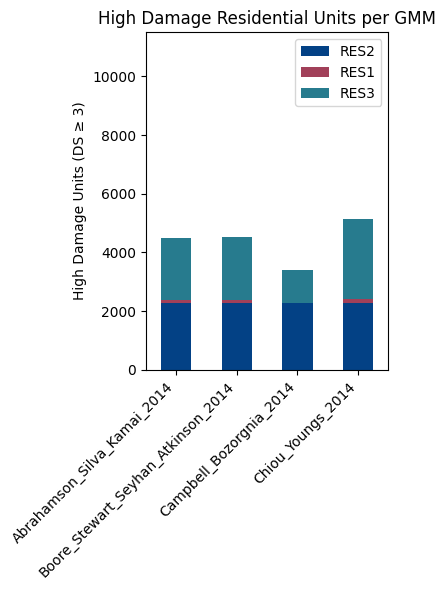

In [75]:

fig, ax = plt.subplots(figsize=(4, 6))
units_df.T.plot(kind="bar",stacked=True,ax=ax) #, color = colors) #[colors[3],colors[2],colors[0],colors[4]])

ax.set_ylabel("High Damage Units (DS ≥ 3)")
ax.set_xlabel("")
ax.set_title("High Damage Residential Units per GMM")
ax.legend(loc="upper right")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_ylim([0, 11500])
plt.tight_layout()
plt.show()
